# CROCUS Data Access

This notebook demonstrates how to access sensor data from the CROCUS 
(Community Research on Climate and Urban Science) network of Waggle/Sage
nodes deployed across Chicagoland. Check current sensor availability and recent data through the Sage portal:

  - All nodes: https://portal.sagecontinuum.org/nodes
  - NEIU node:  https://portal.sagecontinuum.org/nodes/W08D

CROCUS data is also archived at:

  - https://data.ess-dive.lbl.gov/portals/crocus/Data


### Network Notes

- All CROCUS WXT and AQT nodes were offline approximately December 2025 &ndash; 
  March 2026 during a network-wide maintenance period.
- The 5-minute averaging plugin was deployed across all nodes when they came 
  back online in April 2026. Historical WXT data prior to this transition was 
  sampled at >1Hz; historical AQT data was at 1-minute intervals.
- All data returned by the query functions is resampled to 5-minute means for 
  consistency across years.


## Audience

This notebook is designed for students who are new to Python or early in their data science journey. 
The `sage_utils.py` functions return data in **wide format** &mdash; one column per variable, one row 
per timestamp &mdash; which is familiar to anyone who has worked with a spreadsheet.  This package is 
requires the sage data client. You can use *pip* to o install this package from https://github.com/sagecontinuum/sage-data-client.

`pip install sage-data-client`

The native Sage Data Client returns data in **long format** &mdash; one row per
measurement &mdash; which is more flexible for certain analyses but requires
additional wrangling steps. Experienced Python users who prefer the native
format should refer to:
  - https://sagecontinuum.org/docs/tutorials/
  - https://github.com/sagecontinuum/sage-data-client
  - https://crocus-urban.github.io/instrument-cookbooks/

The source code in `sage_utils.py` and `crocus_sites.py` is documented
and readable &mdash; students are encouraged to look at how the functions work
and adapt them for their own projects.

### CROCUSSite Class

The `CROCUSSite` class in `crocus_sites.py` contains metadata for each CROCUS 
field site including full name, Waggle/Virtual Sage Node ID (vsn), 
site abbreviation, geographic coordinates, and sensor availability flags.
Each site is a `CROCUSSite` instance accessible directly by name (e.g. `NEIU`, `CSU`).
This allows users to pass a site's memorable abbreviation (e.g. *NEIU*) 
to the query functions, rather than the VSN ID (e.g. *W08D*).

### sage_utils

The querying functions below are found in the local package sage_utils. These
functions return wide-format DataFrames for each device with intuitive column names, missing values replaced with NaN.  WXT and AQT data resampled to a consistent 5-minute resolution regardless of the underlying sampling rate.

 - `query_aqt(site,start,end)`  returns a wide air quality data frame

 - `query_wxt(site,start,end)`  returns a wide weather data frame
 
 - `query_bme(site,start,end)`  returns a wide BME (P,T,H) sensor data frame

 - `query_sapflow(site,start,end)` returns dictionary of sapflow data frames

 - `query_mfr(site,start,end)`     returns a dictionary of MFR soil data


In [38]:
# Run this cell first in Google Colab.
# It is harmless in a normal local Jupyter session.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content
    !git clone -q https://github.com/gregorywanderson/crocus.git
    %cd /content/crocus
    !pip install -q -r requirements.txt

# Make sure Python can find local modules such as sage_utils.py
# and crocus_sites.py.
if IN_COLAB:
    sys.path.insert(0, "/content/crocus")
else:
    sys.path.insert(0, str(Path.cwd()))

In [39]:
# Standard library
import datetime as dt
import importlib
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local
import crocus_sites
import sage_utils

importlib.reload(crocus_sites)
importlib.reload(sage_utils)

from crocus_sites import (
    ALL_SITES,
    ATMOS, 
    BIG, 
    CCICS, 
    CSU,
    DOWN,
    HUM, 
    IBP,
    NEIU, 
    NU, 
    SHEDD, 
    UIC,
    VLPK,
)
from sage_utils import (
    query_aqt, 
    query_wxt,
    query_sapflow, 
    query_mfr,
    query_bme680, 
    last_n_hours
)

ssl._create_default_https_context = ssl._create_unverified_context

### Site list

The code block below lists available sites, their abbreviations and VSN IDs.

In [40]:
for site in ALL_SITES:
    print(f"{site.abbr:<8} {site.vsn}  {site.full_name}")

ATMOS    W0A4  Argonne Testbed for Multiscale Observational Science
BIG      W0A0  Blacks in Green (West Woodlawn)
CCICS    W08B  Carruthers Center for Inner City Studies — Bronzeville (NEIU satellite)
CSU      W08E  Chicago State University
DOWN     W09D  Downers Grove
HUM      W0A1  Humboldt Park
IBP      W07C  Indian Boundary Prairies (TNC/NEIU)
NEIU     W08D  Northeastern Illinois University
NU       W099  Northwestern University
SHEDD    W09E  Shedd Aquarium
UIC      W096  University of Illinois Chicago
VLPK     W095  Villa Park


In [41]:
# Set a SITE for use throughout the rest of this notebook.
SITE = NU  # change this to CSU, UIC, NEIU, NU, BIG, etc. to query a different site
print(f"Querying: {SITE.full_name} ({SITE.vsn})")

Querying: Northwestern University (W099)


To see documentation for any function, type the function name followed by ?
An example is provided in the block below.

In [42]:
query_aqt?

Signature: query_aqt(site, start, end=None, resample='5min')
Docstring:
Query Vaisala AQT530 air quality transmitter data from the Sage/Waggle API.
Returns PM1, PM2.5, PM10, CO, NO, NO2, O3, temperature, humidity and
pressure resampled to a consistent 5-minute resolution.
NB: Some nodes have PM sensors that have stopped functioning — check
site status before interpreting PM data.

Parameters
----------
site: CROCUSSite
     Site object from crocus_sites.py, e.g. NEIU
start : str
    Start datetime, absolute e.g. '2023-06-01' or relative e.g. '-1h'
end : str, optional
    End datetime. If omitted, defaults to now.
resample : str, optional
    Pandas offset string for output resolution, e.g. '1min', '5min', '1h'.
    Default is RESAMPLE_INTERVAL. Should be >= native data resolution.    

Returns
-------
pd.DataFrame resampled to `resample` interval with UTC DatetimeIndex
and columns:
    humidity, pressure, temp, co, no, no2, o3, pm1, pm10, pm25, vsn, sensor
File:      ~/py/crocus/sage_u

## Vaisala Weather Transmitter WXT530 

Temperature, humidity, pressure, rain accumulation, wind direction, wind speed.
Datasheet: https://docs.vaisala.com/v/u/B211500EN-K/en-US

### Recent Data (Last N hours)

In [43]:
start, end = last_n_hours(1)  # return(N) a (start,end) tuple for last N hours
PLOT_WXT = False

if not SITE.has_wxt:
    print(f"{SITE.abbr} has no WXT configured.")
else:
    wxt_last_hour = query_wxt(SITE, start, end)
    PLOT_WXT = not wxt_last_hour.empty
    print(wxt_last_hour.columns)
    if wxt_last_hour.empty:
        print(f"No WXT data returned for {SITE.abbr}.")
    else:
        wxt_last_hour.head()

Index(['humidity', 'pressure', 'temp', 'rain', 'wind_dir', 'wind_speed', 'vsn',
       'sensor'],
      dtype='str')


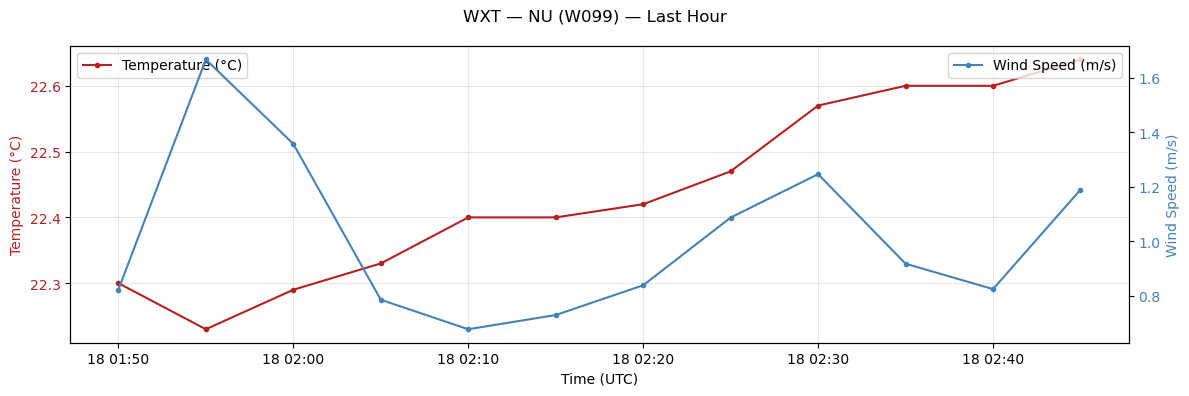

In [44]:
if PLOT_WXT:

    fig, ax1 = plt.subplots(figsize=(12, 4))

    ax1.plot(
        wxt_last_hour.index,
        wxt_last_hour["temp"],
        marker="o",
        markersize=3,
        color="firebrick",
        label="Temperature (°C)",
    )
    ax1.set_ylabel("Temperature (°C)", color="firebrick")
    ax1.tick_params(axis="y", labelcolor="firebrick")
    ax1.set_xlabel("Time (UTC)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        wxt_last_hour.index,
        wxt_last_hour["wind_speed"],
        marker="o",
        markersize=3,
        color="steelblue",
        label="Wind Speed (m/s)",
        )
    ax2.set_ylabel("Wind Speed (m/s)", color="steelblue")
    ax2.tick_params(axis="y", labelcolor="steelblue")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    fig.suptitle(f"WXT — {SITE.abbr} ({SITE.vsn}) — Last Hour", fontsize=12)
    fig.tight_layout()
    plt.show()

## Vaisala Air Quality Transmitter AQT560

PM<sub>10</sub>, PM<sub>2.5</sub>, PM<sub>1</sub>, 
CO, NO, NO<sub>2</sub>, O<sub>3</sub>, temperature, humidity and pressure.
Datasheet: https://www.vaisala.com/sites/default/files/documents/WEA-EUI-ProductSpotlight-AQT560-B212846EN.pdf

NB Several nodes have PM sensors which stopped functioning. 

In [45]:
start, end = last_n_hours(1)
PLOT_AQT = False

if not SITE.has_aqt:
    print(f"{SITE.abbr} has no AQT configured.")
else:
    aqt_last_hour = query_aqt(SITE, start, end)
    PLOT_AQT = not aqt_last_hour.empty
    print(aqt_last_hour.columns)
    if aqt_last_hour.empty:
        print(f"No AQT data returned for {SITE.abbr}.")
    else:
        aqt_last_hour.head()

Index(['humidity', 'pressure', 'temp', 'co', 'no', 'no2', 'o3', 'pm1', 'pm10',
       'pm25', 'vsn', 'sensor'],
      dtype='str')


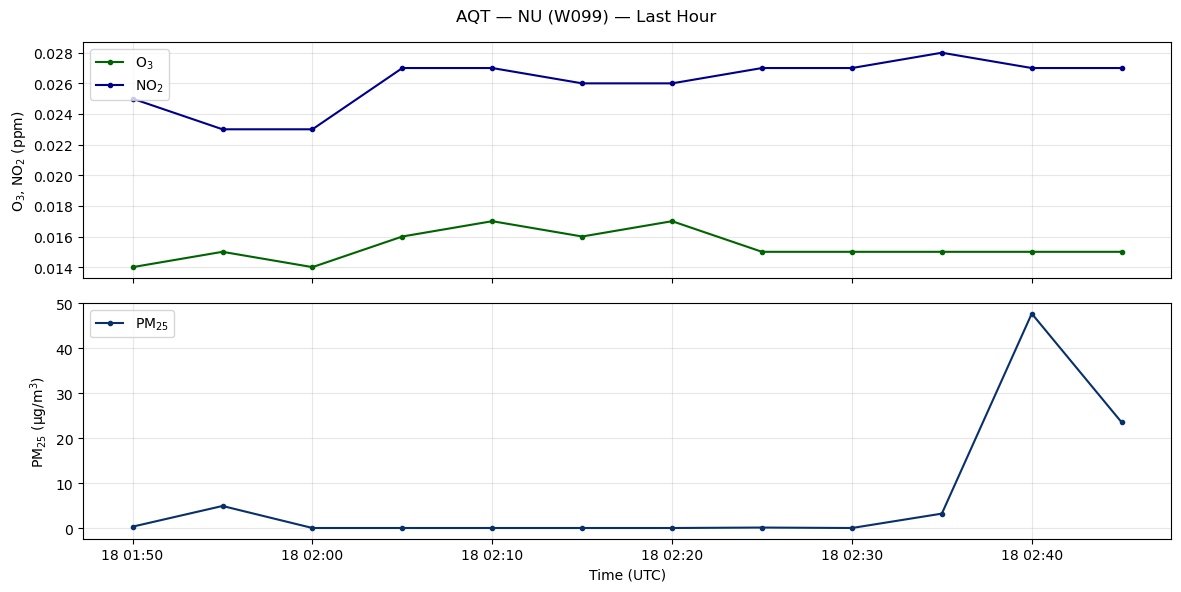

In [46]:
if PLOT_AQT:

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(aqt_last_hour.index, aqt_last_hour['o3'],
         marker='o', markersize=3, label='O$_3$', color='darkgreen')
    ax1.plot(aqt_last_hour.index, aqt_last_hour['no2'],
         marker='o', markersize=3, label='NO$_2$', color='darkblue')
    ax1.set_ylabel('O$_3$, NO$_2$ (ppm)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2.plot(aqt_last_hour.index, aqt_last_hour['pm25'],
         marker='o', markersize=3, label='PM$_{25}$', color='#08306b')
    ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
    ax2.set_xlabel('Time (UTC)')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — Last Hour', fontsize=12)
    fig.tight_layout()
    plt.show()

## Data with Specified Date Range

In [47]:
# This can take 1.5s to run
START = "2026-05-01"  # start is at the beginning of this day
END   = "2026-05-10"  # end is at the beginning of this day

df_aqt = query_aqt(SITE,START,END)

WXT queries can take  ~6-8 minutes/day for 2023 data due to >1Hz historical sampling rate.

In [48]:
df_wxt = query_wxt(SITE,START,END)

In [49]:
if not df_wxt.empty:
    print(f"df_aqt: {df_aqt.shape}, {df_aqt.memory_usage(deep=True).sum() / 1e6:.2f} MB")
    print(f"df_wxt: {df_wxt.shape}, {df_wxt.memory_usage(deep=True).sum() / 1e6:.2f} MB")

df_aqt: (1501, 12), 0.18 MB
df_wxt: (1501, 8), 0.14 MB


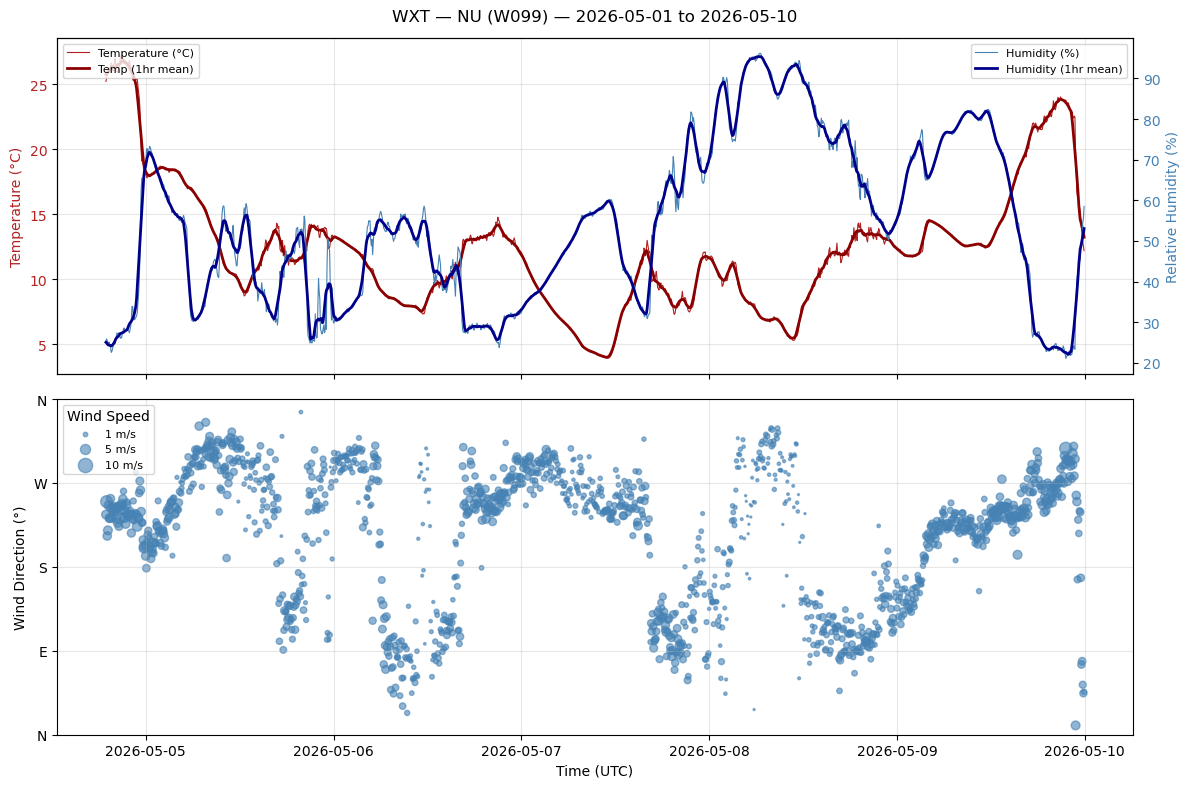

In [50]:
if not df_wxt.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Panel 1: Temperature and Humidity ---
    ax1.plot(df_wxt.index, df_wxt['temp'],
             color='firebrick', linewidth=0.8, label='Temperature (°C)')
    ax1.plot(df_wxt.index,
             df_wxt['temp'].rolling('60min', center=True).mean(),
             color='darkred', linewidth=2, label='Temp (1hr mean)')
    ax1.set_ylabel('Temperature (°C)', color='firebrick')
    ax1.tick_params(axis='y', labelcolor='firebrick')
    ax1.grid(True, alpha=0.3)

    ax1b = ax1.twinx()
    ax1b.plot(df_wxt.index, df_wxt['humidity'],
          color='steelblue', linewidth=0.8, label='Humidity (%)')
    ax1b.plot(df_wxt.index,
              df_wxt['humidity'].rolling('60min', center=True).mean(),
              color='darkblue', linewidth=2, label='Humidity (1hr mean)')
    ax1b.set_ylabel('Relative Humidity (%)', color='steelblue')
    ax1b.tick_params(axis='y', labelcolor='steelblue')

    ax1.legend(loc='upper left', fontsize=8)
    ax1b.legend(loc='upper right', fontsize=8)

    # --- Panel 2: Wind direction, dot size proportional to wind speed ---
    # Normalize wind speed for marker size — scale to reasonable dot range
    speed        = df_wxt['wind_speed'].fillna(0)
    marker_sizes = (speed / speed.max() * 80).clip(lower=2)

    ax2.scatter(df_wxt.index, df_wxt['wind_dir'],
                s=marker_sizes,
                color='steelblue', alpha=0.6)
    ax2.set_ylabel('Wind Direction (°)')
    ax2.set_ylim(0, 360)
    ax2.set_yticks([0, 90, 180, 270, 360])
    ax2.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
    ax2.set_xlabel('Time (UTC)')
    ax2.grid(True, alpha=0.3)

    # Add a size legend for wind speed
    for speed_val, label in [(1, '1 m/s'), (5, '5 m/s'), (10, '10 m/s')]:
        size = speed_val / df_wxt['wind_speed'].max() * 80
        ax2.scatter([], [], s=max(size, 2), color='steelblue',
                alpha=0.6, label=label)
    ax2.legend(loc='upper left', fontsize=8, title='Wind Speed')

    fig.suptitle(f'WXT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

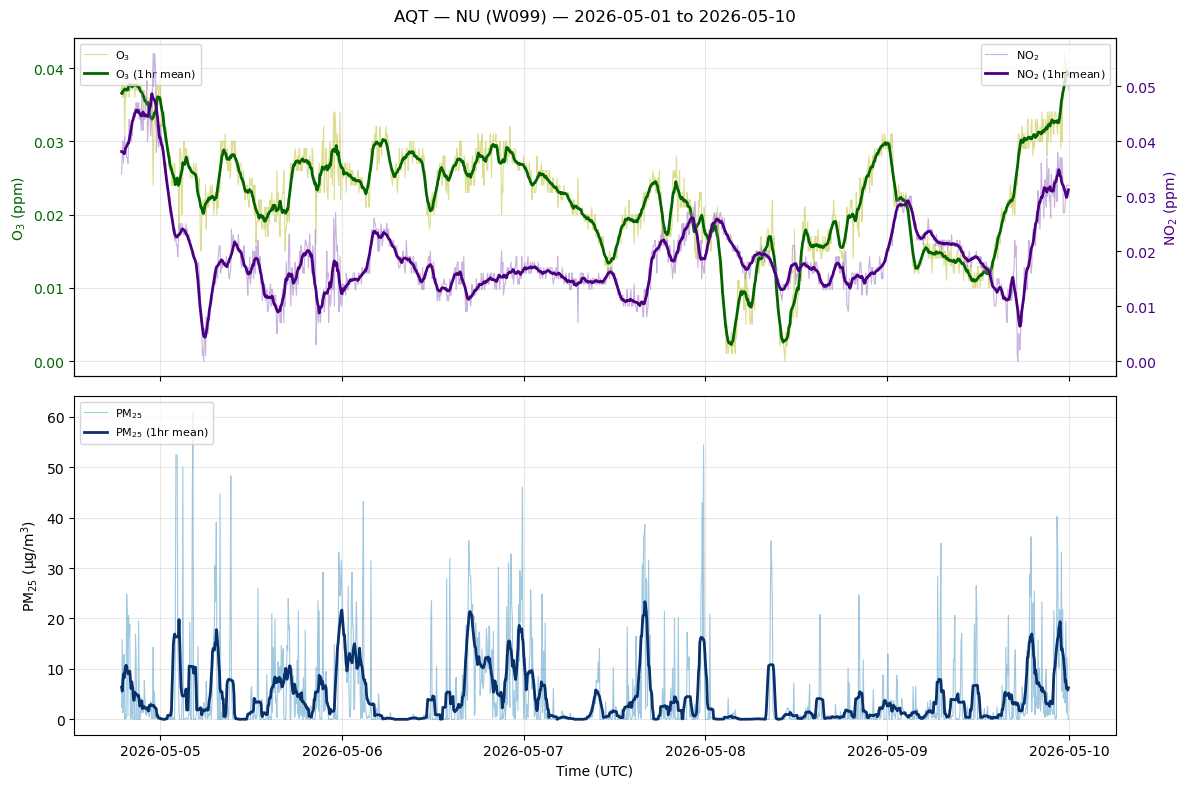

In [51]:
if not df_aqt.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Panel 1: O3 and NO2 ---
    ax1.plot(df_aqt.index, df_aqt['o3'],
            color='tab:olive', linewidth=0.8, alpha=0.5, label='O$_3$')
    ax1.plot(df_aqt.index,
            df_aqt['o3'].rolling('60min', center=True).mean(),
           color='darkgreen', linewidth=2, label='O$_3$ (1hr mean)')
    ax1.set_ylabel('O$_3$ (ppm)', color='darkgreen')
    ax1.tick_params(axis='y', labelcolor='darkgreen')
    ax1.grid(True, alpha=0.3)

    ax1b = ax1.twinx()
    ax1b.plot(df_aqt.index, df_aqt['no2'],
              color='tab:purple', linewidth=0.8, alpha=0.5, label='NO$_2$')
    ax1b.plot(df_aqt.index,
              df_aqt['no2'].rolling('60min', center=True).mean(),
              color='indigo', linewidth=2, label='NO$_2$ (1hr mean)')
    ax1b.set_ylabel('NO$_2$ (ppm)', color='indigo')
    ax1b.tick_params(axis='y', labelcolor='indigo')

    ax1.legend(loc='upper left', fontsize=8)
    ax1b.legend(loc='upper right', fontsize=8)

    # --- Panel 2: PM2.5 ---
    ax2.plot(df_aqt.index, df_aqt['pm25'],
             color='#4393c3', linewidth=0.8, alpha=0.5, label='PM$_{25}$')
    ax2.plot(df_aqt.index,
             df_aqt['pm25'].rolling('60min', center=True).mean(),
            color='#08306b', linewidth=2, label='PM$_{25}$ (1hr mean)')
    ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
    ax2.set_xlabel('Time (UTC)')
    ax2.legend(loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

## Sap Flow Meters

These devices communicate to the site Waggle node with a LoRaWAN (Long Range Wide Area Network).

In [52]:
start, end = last_n_hours(24)
PLOT_SAPFLOW = False
sapflow = None

if not SITE.has_sapflow:
    print(f"{SITE.abbr} has no sap flow sensors — skipping.")
    PLOT_SAPFLOW = False
else:
    sapflow = query_sapflow(SITE, start, end)
    PLOT_SAPFLOW = bool(sapflow)
    if not PLOT_SAPFLOW:
        print(f"No sap flow data returned for {SITE.abbr}.")
    else:
        print("Trees with data:", list(sapflow.keys()))

Trees with data: ['maple_1', 'maple_2', 'oak_1', 'oak_2', 'maple_3']


In [53]:
if PLOT_SAPFLOW:
    # Show which trees returned data
    print("Trees with data:", list(sapflow.keys()))

    # Inspect one tree
    if sapflow:
        first = list(sapflow.keys())[0]
        print(f"\n{first}:")
        print(sapflow[first].head())
        print(sapflow[first].dtypes)

Trees with data: ['maple_1', 'maple_2', 'oak_1', 'oak_2', 'maple_3']

maple_1:
name                                 battery_voltage  inner  outer   vsn  \
timestamp                                                                  
2026-08-17 03:04:10.411387904+00:00             4.11  4.551  2.693  W099   
2026-08-17 03:24:04.098141952+00:00             4.11  4.706  2.357  W099   
2026-08-17 03:44:10.626230016+00:00             4.11  4.518  2.452  W099   
2026-08-17 04:04:04.275017984+00:00             4.10  4.349  2.118  W099   
2026-08-17 04:24:01.792105984+00:00             4.10  4.009  2.067  W099   

name                                   serial  
timestamp                                      
2026-08-17 03:04:10.411387904+00:00  SX61NA0Y  
2026-08-17 03:24:04.098141952+00:00  SX61NA0Y  
2026-08-17 03:44:10.626230016+00:00  SX61NA0Y  
2026-08-17 04:04:04.275017984+00:00  SX61NA0Y  
2026-08-17 04:24:01.792105984+00:00  SX61NA0Y  
name
battery_voltage    float64
inner              f

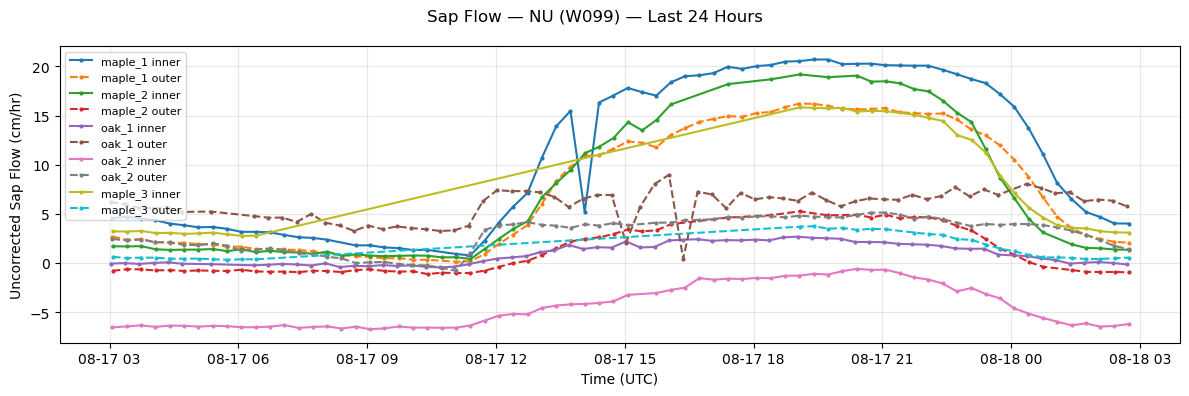

In [54]:
if sapflow:
    fig, ax = plt.subplots(figsize=(12, 4))

    for label, df in sapflow.items():
        ax.plot(df.index, df['inner'],
                marker='o', markersize=2, label=f'{label} inner')
        ax.plot(df.index, df['outer'],
                marker='o', markersize=2, linestyle='--', label=f'{label} outer')

    ax.set_ylabel('Uncorrected Sap Flow (cm/hr)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.suptitle(f'Sap Flow — {SITE.abbr} ({SITE.vsn}) — Last 24 Hours', fontsize=12)
    fig.tight_layout()
    plt.savefig(f'figures/{SITE.abbr}_sapflow.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No sap flow data available.")

In [55]:
# A short inspection of reporting and battery voltage range
if sapflow:
    for label, df in sapflow.items():
        print(f"{label}: {len(df)} rows, "
            f"{df['inner'].isna().sum()} NaN inner, "
            f"battery range {df['battery_voltage'].min():.2f}–{df['battery_voltage'].max():.2f}V")

maple_1: 70 rows, 0 NaN inner, battery range 4.06–4.19V
maple_2: 63 rows, 0 NaN inner, battery range 4.00–4.19V
oak_1: 68 rows, 0 NaN inner, battery range 4.03–4.17V
oak_2: 71 rows, 0 NaN inner, battery range 4.06–4.19V
maple_3: 34 rows, 0 NaN inner, battery range 3.66–3.89V


## Multi-Function Research (MFR) Soil Data

Air temperature, pressure, relative humidity, water conductivity, water depth, water temperature, heat flux, soil temperature, ... and moisture at multiple depths. This device communicates to the site Waggle node with a LoRaWAN (Long Range Wide Area Network). 

 - https://ictinternational.com/wp-content/uploads/2023/06/MFR-NODE-L-Manual.pdf

In [56]:
#start, end = last_n_hours(24)   # Last 24 hours
START = '2026-03-01'
END   = '2026-05-20'
mfr = None
PLOT_MFR = False

if not SITE.has_mfr:
    print(f"{SITE.abbr} has no MFR nodes — skipping.")
    PLOT_MFR = False
else:
    mfr = query_mfr(SITE, START, END)
    PLOT_MFR = bool(mfr)
    # Print MFR sub-site serial numbers and labels for this site
    print(SITE.mfr)
    if not PLOT_MFR:
        print(f"No MFR data returned for {SITE.abbr}.")

{'MNLA4O104': {'label': 'grove', 'lat': 42.05258, 'lon': -87.67682}}


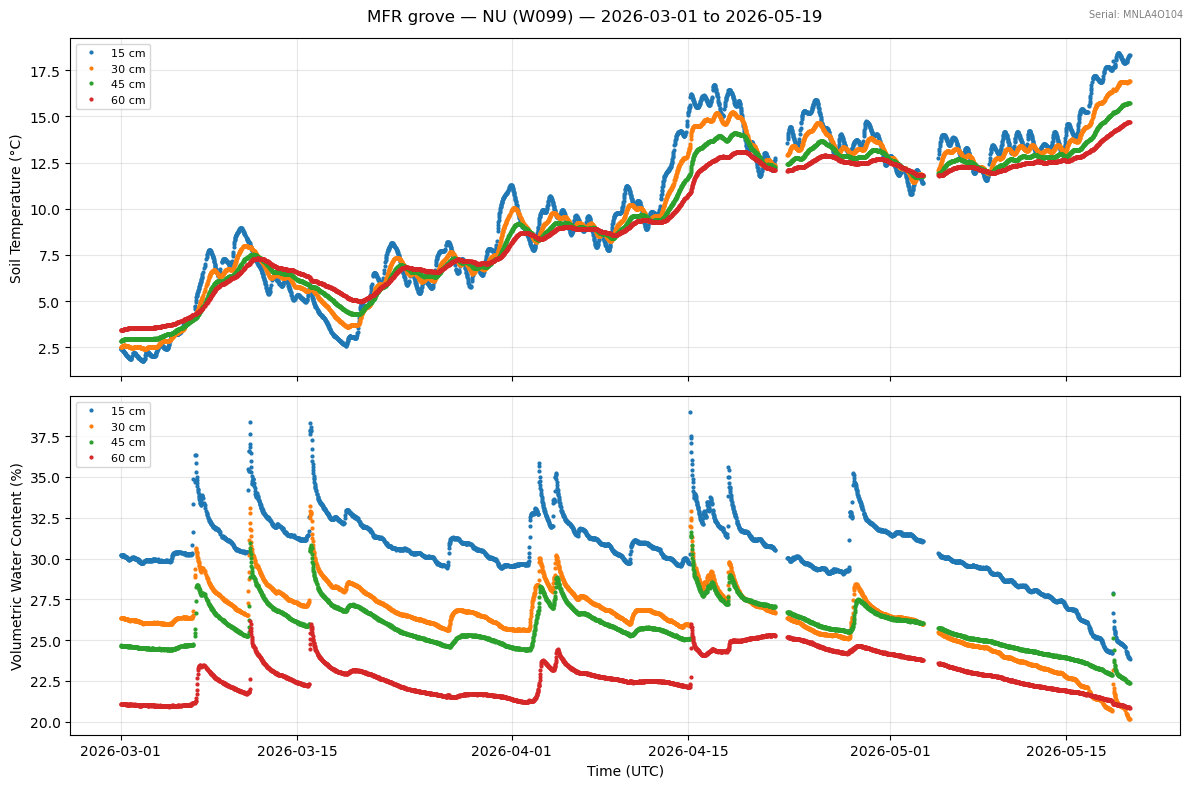

In [57]:
if mfr:
    # Compute common y-axis limits across all sites
    temp_min = min(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].min().min() 
                   for df in mfr.values())
    temp_max = max(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].max().max() 
                   for df in mfr.values())
    vwc_min  = min(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].min().min() 
                   for df in mfr.values())
    vwc_max  = max(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].max().max() 
                   for df in mfr.values())

    # Add a small margin
    temp_pad = (temp_max - temp_min) * 0.05
    vwc_pad  = (vwc_max  - vwc_min)  * 0.05

    for label, df in mfr.items():
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        for col, depth in [('temp_15cm', '15 cm'), ('temp_30cm', '30 cm'),
                            ('temp_45cm', '45 cm'), ('temp_60cm', '60 cm')]:
            if col in df.columns:
                ax1.plot(df.index, df[col], linestyle='none', marker='o',
                         label=depth, markersize=2)
        ax1.set_ylim(temp_min - temp_pad, temp_max + temp_pad)
        ax1.set_ylabel('Soil Temperature (°C)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        for col, depth in [('vwc_15cm', '15 cm'), ('vwc_30cm', '30 cm'),
                            ('vwc_45cm', '45 cm'), ('vwc_60cm', '60 cm')]:
            if col in df.columns:
                ax2.plot(df.index, df[col],
                         linestyle='none', marker='o', markersize=2,
                         label=depth)
        ax2.set_ylim(vwc_min - vwc_pad, vwc_max + vwc_pad)
        ax2.set_ylabel('Volumetric Water Content (%)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'MFR {label} — {SITE.abbr} ({SITE.vsn}) — {df.index.min().date()} to {df.index.max().date()}',
                     fontsize=12)
        # Add serial number as small annotation
        serial = next(k for k, v in SITE.mfr.items() if v['label'] == label)
        fig.text(0.99, 0.98, f'Serial: {serial}',
            ha='right', va='top',
            fontsize=7, color='0.5',
            transform=fig.transFigure)
        
        fig.tight_layout()
        plt.savefig(f'figures/{SITE.abbr}_mfr_{label}_soil.png', dpi=150, bbox_inches='tight')
        plt.show()

NB The savannah soil texture at NEIU is mostly clay which may be responsible for saturation and the narrow range of VWC.

In [58]:
# Simple soil statistics

if mfr:
    for label, df in mfr.items():
        print(f"\n{label}:")
        print(f"  Shape: {df.shape}")
        print(f"  Date range: {df.index.min()} to {df.index.max()}")
        print(f"\n  Column statistics:")
        cols = ['temp_15cm', 'temp_30cm', 'temp_45cm', 'temp_60cm',
                'vwc_15cm',  'vwc_30cm',  'vwc_45cm',  'vwc_60cm']
        for col in cols:
            if col in df.columns:
                valid = df[col].dropna()
                print(f"  {col:12}: n={len(valid):4d}  "
                      f"min={valid.min():7.2f}  "
                      f"max={valid.max():7.2f}  "
                      f"mean={valid.mean():7.2f}")


grove:
  Shape: (17761, 21)
  Date range: 2026-03-01 00:17:28.469623040+00:00 to 2026-05-19 23:59:42.068912896+00:00

  Column statistics:
  temp_15cm   : n=3418  min=   1.75  max=  18.41  mean=  10.17
  temp_30cm   : n=3416  min=   2.41  max=  16.94  mean=   9.87
  temp_45cm   : n=3421  min=   2.84  max=  15.75  mean=   9.56
  temp_60cm   : n=3416  min=   3.41  max=  14.72  mean=   9.39
  vwc_15cm    : n=3418  min=  23.87  max=  39.00  mean=  30.58
  vwc_30cm    : n=3419  min=  20.14  max=  33.19  mean=  26.35
  vwc_45cm    : n=3418  min=  22.34  max=  31.60  mean=  25.84
  vwc_60cm    : n=3418  min=  20.84  max=  26.16  mean=  22.86


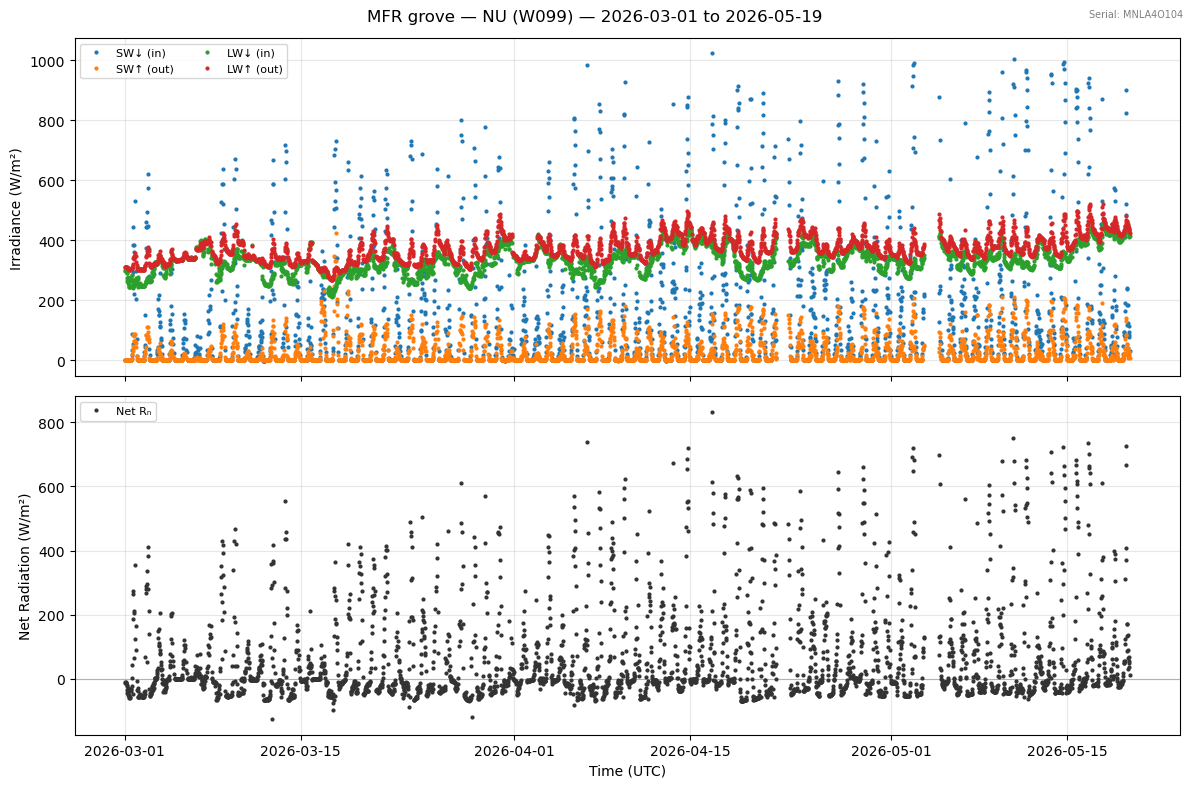

In [64]:
# MFR radiation — SN500 four-component + net radiation
# Note: radiation reports ~every 13-16 min, sparser than the soil channels.
if mfr:
    RAD_COMPONENTS = [
        ('in_shortwave',  'SW↓ (in)'),
        ('out_shortwave', 'SW↑ (out)'),
        ('in_longwave',   'LW↓ (in)'),
        ('out_longwave',  'LW↑ (out)'),
    ]

    # Common y-limits across sub-sites, ignoring all-NaN frames
    def _finite_minmax(cols):
        lo = min((df[cols].min().min() for df in mfr.values()
                  if df[cols].notna().any().any()), default=float('nan'))
        hi = max((df[cols].max().max() for df in mfr.values()
                  if df[cols].notna().any().any()), default=float('nan'))
        return lo, hi

    comp_cols = [c for c, _ in RAD_COMPONENTS]
    comp_min, comp_max = _finite_minmax(comp_cols)

    # Net radiation Rn = (SWin - SWout) + (LWin - LWout), computed per frame
    net_min = min((( (df['in_shortwave'] - df['out_shortwave'])
                    + (df['in_longwave']  - df['out_longwave']) ).min()
                   for df in mfr.values()), default=float('nan'))
    net_max = max((( (df['in_shortwave'] - df['out_shortwave'])
                    + (df['in_longwave']  - df['out_longwave']) ).max()
                   for df in mfr.values()), default=float('nan'))

    import math
    comp_pad = (comp_max - comp_min) * 0.05 if math.isfinite(comp_max - comp_min) else 1.0
    net_pad  = (net_max  - net_min)  * 0.05 if math.isfinite(net_max  - net_min)  else 1.0

    for label, df in mfr.items():
        net = ((df['in_shortwave'] - df['out_shortwave'])
               + (df['in_longwave'] - df['out_longwave']))

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        for col, lbl in RAD_COMPONENTS:
            if col in df.columns and df[col].notna().any():
                ax1.plot(df.index, df[col], linestyle='none', marker='o',
                         markersize=2, label=lbl)
        if math.isfinite(comp_min) and math.isfinite(comp_max):
            ax1.set_ylim(comp_min - comp_pad, comp_max + comp_pad)
        ax1.set_ylabel('Irradiance (W/m²)')
        ax1.legend(loc='upper left', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.3)

        ax2.plot(df.index, net, linestyle='none', marker='o', markersize=2,
                 color='0.2', label='Net Rₙ')
        ax2.axhline(0, color='0.7', linewidth=0.8, zorder=0)
        if math.isfinite(net_min) and math.isfinite(net_max):
            ax2.set_ylim(net_min - net_pad, net_max + net_pad)
        ax2.set_ylabel('Net Radiation (W/m²)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'MFR {label} — {SITE.abbr} ({SITE.vsn}) — '
                     f'{df.index.min().date()} to {df.index.max().date()}',
                     fontsize=12)
        serial = next(k for k, v in SITE.mfr.items() if v['label'] == label)
        fig.text(0.99, 0.98, f'Serial: {serial}', ha='right', va='top',
                 fontsize=7, color='0.5', transform=fig.transFigure)

        fig.tight_layout()
        plt.savefig(f'figures/{SITE.abbr}_mfr_{label}_radiation.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

In [65]:
# Simple radiation statistics
if mfr:
    for label, df in mfr.items():
        print(f"\n{label}:")
        cols = ['in_shortwave', 'out_shortwave', 'in_longwave', 'out_longwave']
        for col in cols:
            if col in df.columns:
                valid = df[col].dropna()
                if len(valid):
                    print(f"  {col:14}: n={len(valid):4d}  "
                          f"min={valid.min():8.2f}  "
                          f"max={valid.max():8.2f}  "
                          f"mean={valid.mean():8.2f}")
                else:
                    print(f"  {col:14}: no data")
        net = ((df['in_shortwave'] - df['out_shortwave'])
               + (df['in_longwave'] - df['out_longwave'])).dropna()
        if len(net):
            print(f"  {'net_Rn':14}: n={len(net):4d}  "
                  f"min={net.min():8.2f}  max={net.max():8.2f}  "
                  f"mean={net.mean():8.2f}")


grove:
  in_shortwave  : n=3579  min=   -3.30  max= 1022.70  mean=  118.52
  out_shortwave : n=3583  min=   -1.10  max=  422.20  mean=   26.28
  in_longwave   : n=3581  min=  211.60  max=  459.90  mean=  335.06
  out_longwave  : n=3580  min=  267.10  max=  521.70  mean=  371.61
  net_Rn        : n=3571  min= -126.50  max=  833.20  mean=   55.67


## Met Comparison: WXT, AQT, BME (T, P, H)

AQT returns Pa, WXT and BME680 (https://www.waveshare.com/wiki/Bme680)  report hPa.

In [59]:
# Uses START/END from the cell above, or fall back to last 24 hours
try:
    start_met, end_met = START, END
except NameError:
    start_met, end_met = last_n_hours(24)

df_wxt = query_wxt(SITE, start_met, end_met) if SITE.has_wxt else pd.DataFrame()
df_aqt = query_aqt(SITE, start_met, end_met) if SITE.has_aqt else pd.DataFrame()
df_bme = query_bme680(SITE, start_met, end_met) if SITE.has_bme680 else pd.DataFrame()

In [60]:
ROLL = '60min'   # rolling mean window — adjust as needed

# Build display labels using actual sensor model from metadata
def sensor_label(df, fallback):
    if df.empty or 'sensor' not in df.columns:
        return fallback
    return df['sensor'].iloc[0]

wxt_label = sensor_label(df_wxt, 'WXT')
aqt_label = sensor_label(df_aqt, 'AQT')
bme_label = sensor_label(df_bme, 'BME')

sensor_dfs    = {wxt_label: df_wxt, aqt_label: df_aqt, bme_label: df_bme}
sensor_colors = {wxt_label: 'steelblue', aqt_label: 'firebrick', bme_label: 'darkorange'}
sensor_alpha  = {wxt_label: 0.2, aqt_label: 0.2, bme_label: 0.2}
sensor_ls     = {wxt_label: 'solid', aqt_label: 'dashed', bme_label: 'dotted'}

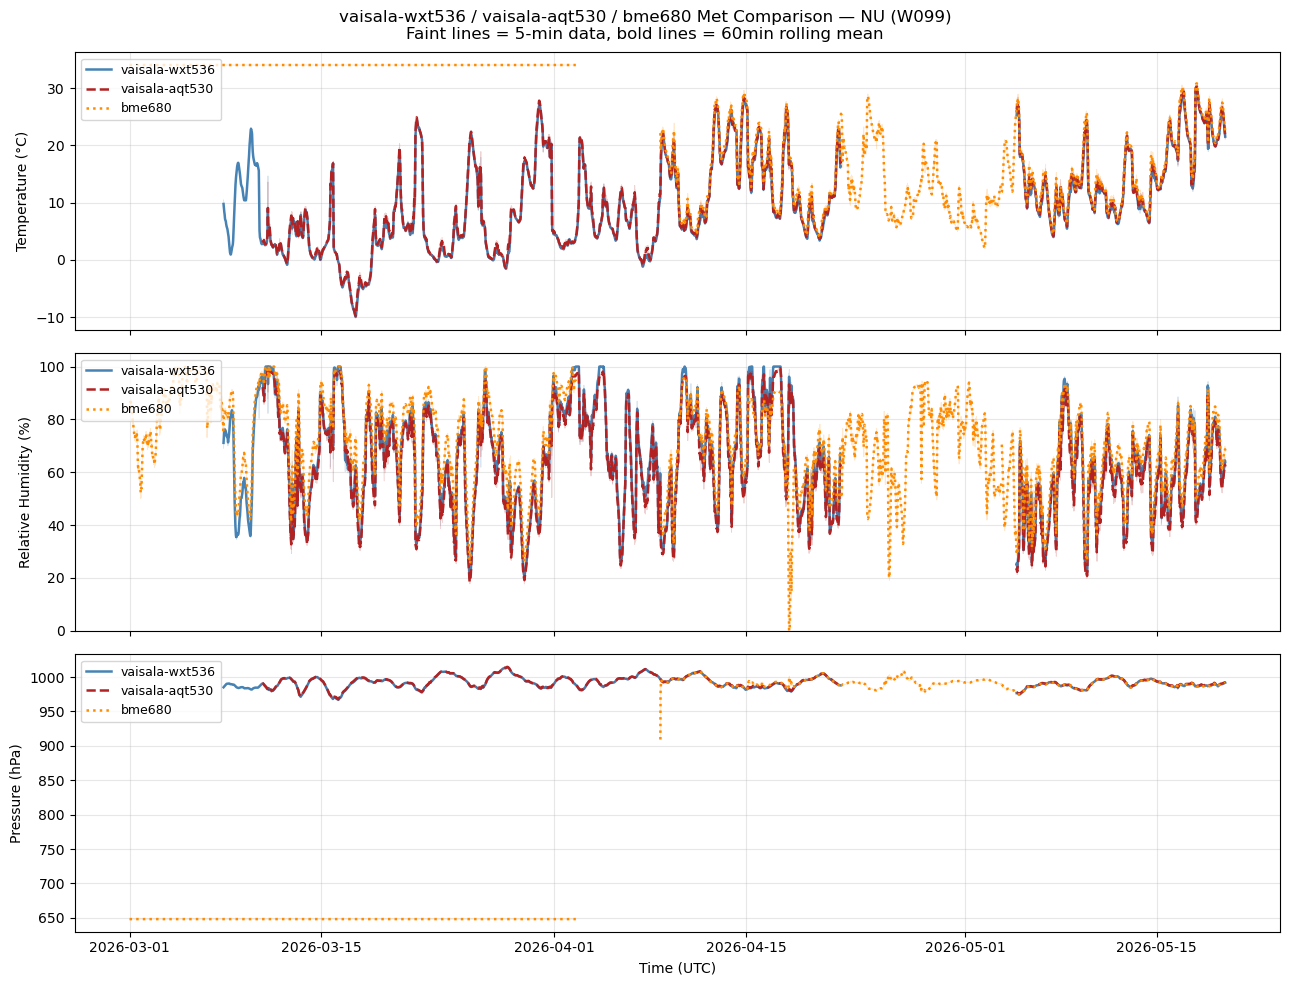

In [61]:

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for name, df in sensor_dfs.items():
    if df.empty:
        continue
    color = sensor_colors[name]

    if 'temp' in df.columns:
        ax1.plot(df.index, df['temp'],
                 color=color, linewidth=0.7, 
                 alpha=sensor_alpha[name])
        ax1.plot(df.index, df['temp'].rolling(ROLL, center=True).mean(),
                 color=color,
                 linestyle=sensor_ls[name],
                 linewidth=1.8, label=name)

    if 'humidity' in df.columns:
        ax2.plot(df.index, df['humidity'],
                 color=color, linewidth=0.7, alpha=sensor_alpha[name])
        ax2.plot(df.index, df['humidity'].rolling(ROLL, center=True).mean(),
                 color=color, 
                 linestyle=sensor_ls[name],
                 linewidth=1.8, 
                 label=name)

    if 'pressure' in df.columns:
        pressure = df['pressure'].copy()
        if pressure.median() > 10000:
            pressure = pressure / 100
        ax3.plot(df.index, pressure,
                 color=color, 
                 linewidth=0.7, 
                 alpha=sensor_alpha[name])
        ax3.plot(df.index, pressure.rolling(ROLL, center=True).mean(),
                 color=color, 
                 linestyle=sensor_ls[name],
                 linewidth=1.8, 
                 label=name)

ax1.set_ylabel('Temperature (°C)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_ylabel('Relative Humidity (%)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

ax3.set_ylabel('Pressure (hPa)')
ax3.set_xlabel('Time (UTC)')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    f'{wxt_label} / {aqt_label} / {bme_label} Met Comparison — {SITE.abbr} ({SITE.vsn})\n'
    f'Faint lines = 5-min data, bold lines = {ROLL} rolling mean',
    fontsize=12
)
fig.tight_layout()
plt.savefig(f"figures/{SITE.abbr}_met_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Temp

In [62]:
df = sage_data_client.query(start="-30h", filter={"vsn": "W08D",
      "name": "in_longwave|out_longwave|out_shortwave|in_shortwave"})
for c in [c for c in df.columns if c.startswith("meta")]:
    print(c, "->", df[c].unique())

meta.applicationId -> <ArrowStringArray>
['5ffdbb51-05c7-431c-960c-3f66088d5fbf']
Length: 1, dtype: str
meta.applicationName -> <ArrowStringArray>
['default']
Length: 1, dtype: str
meta.devAddr -> <ArrowStringArray>
['003f3d94', '019f91bb']
Length: 2, dtype: str
meta.devEui -> <ArrowStringArray>
['2bb2d7ff13d46ca2', '1435db497f628cbb']
Length: 2, dtype: str
meta.deviceName -> <ArrowStringArray>
['MFR node MNLA4O108', 'MFR node MNLA4O107']
Length: 2, dtype: str
meta.deviceProfileId -> <ArrowStringArray>
['8a75fcb0-fc16-4a05-82c3-1b04224417c9']
Length: 1, dtype: str
meta.deviceProfileName -> <ArrowStringArray>
['MFR_node']
Length: 1, dtype: str
meta.host -> <ArrowStringArray>
['0000d83addad1d0b.ws-rpi']
Length: 1, dtype: str
meta.job -> <ArrowStringArray>
['lorawan-listener-2298']
Length: 1, dtype: str
meta.lns -> <ArrowStringArray>
['local_chirpstack']
Length: 1, dtype: str
meta.node -> <ArrowStringArray>
['000048b02d3ae277']
Length: 1, dtype: str
meta.plugin -> <ArrowStringArray>
['reg

In [63]:
from urllib.error import HTTPError
try:
    df = sage_data_client.query(**query_kwargs)
except HTTPError as e:
    if e.code == 500:
        print(f"{site.abbr}: query returned 500 (often an empty/sparse window); "
              f"returning no MFR data.")
        return {}
    raise

SyntaxError: 'return' outside function (228999688.py, line 8)

In [ ]:
mfr = query_mfr(NEIU, '-30h')
for label, d in mfr.items():
    print(label, d[['in_shortwave','out_shortwave','in_longwave','out_longwave']].notna().sum().to_dict())

lawn {'in_shortwave': 59, 'out_shortwave': 58, 'in_longwave': 59, 'out_longwave': 59}
savannah {'in_shortwave': 57, 'out_shortwave': 57, 'in_longwave': 57, 'out_longwave': 57}
